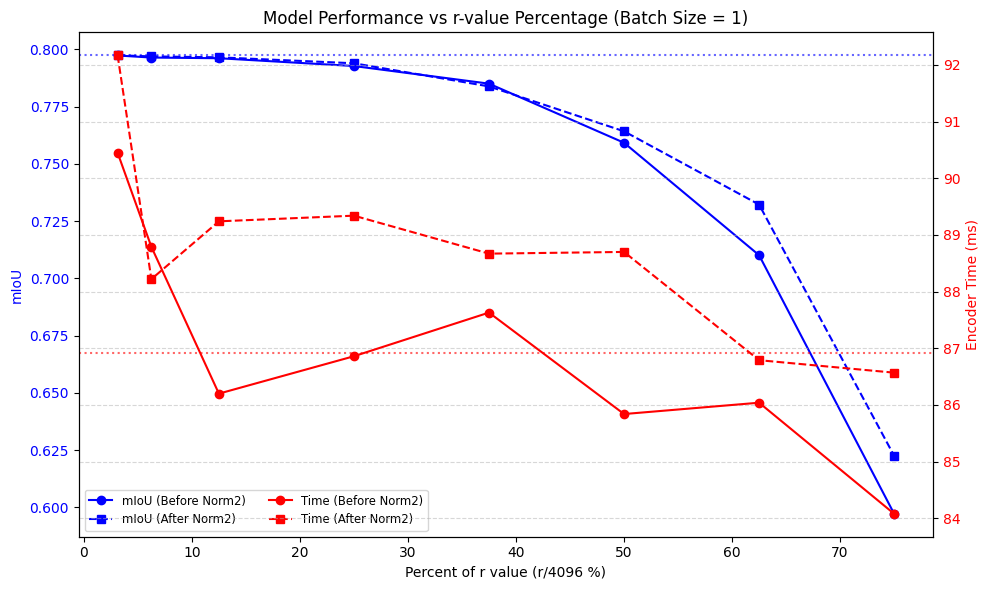

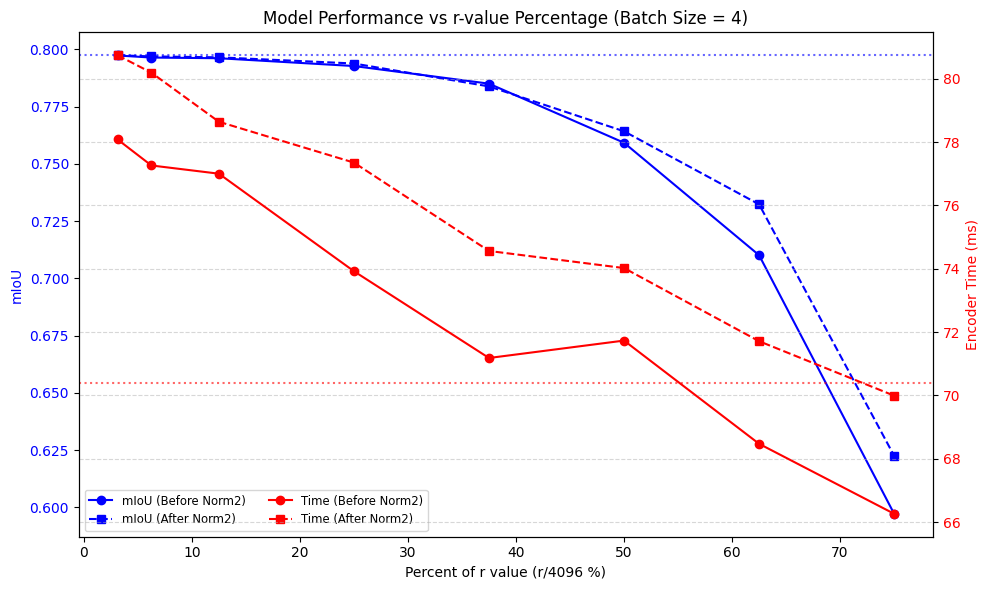

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Data Setup
r_values = np.array([128, 256, 512, 1024, 1536, 2048, 2560, 3072])
x_axis = (r_values / 4096) * 100  # Percent of r value

data = {
    "BS4": {
        "base_miou": 0.7973,
        "base_time": 70.39,
        "before_miou": [0.7973, 0.7964, 0.7961, 0.7927, 0.7850, 0.7592, 0.7101, 0.5972],
        "before_time": [78.08, 77.26, 77.00, 73.92, 71.18, 71.73, 68.47, 66.26],
        "after_miou": [0.7974, 0.7969, 0.7965, 0.7938, 0.7838, 0.7642, 0.7323, 0.6225],
        "after_time": [80.74, 80.19, 78.64, 77.35, 74.56, 74.02, 71.71, 69.99]
    },
    "BS1": {
        "base_miou": 0.7973,
        "base_time": 86.91,
        "before_miou": [0.7973, 0.7964, 0.7961, 0.7927, 0.7850, 0.7592, 0.7101, 0.5972],
        "before_time": [90.45, 88.79, 86.20, 86.86, 87.63, 85.84, 86.04, 84.08],
        "after_miou": [0.7974, 0.7969, 0.7965, 0.7939, 0.7838, 0.7642, 0.7322, 0.6225],
        "after_time": [92.17, 88.22, 89.24, 89.34, 88.67, 88.70, 86.79, 86.57]
    }
}

def plot_batch(batch_key, title):
    fig, ax1 = plt.subplots(figsize=(10, 6))
    d = data[batch_key]

    # --- Left Y-Axis: mIoU ---
    ax1.set_xlabel('Percent of r value (r/4096 %)')
    ax1.set_ylabel('mIoU', color='blue')
    
    # Lines for mIoU
    ln1 = ax1.plot(x_axis, d["before_miou"], 'b-o', label='mIoU (Before Norm2)')
    ln2 = ax1.plot(x_axis, d["after_miou"], 'b--s', label='mIoU (After Norm2)')
    
    # Baseline mIoU
    ax1.axhline(y=d["base_miou"], color='blue', linestyle=':', alpha=0.6, label='Base mIoU')
    ax1.tick_params(axis='y', labelcolor='blue')

    # --- Right Y-Axis: Encoder Time ---
    ax2 = ax1.twinx()
    ax2.set_ylabel('Encoder Time (ms)', color='red')
    
    # Lines for Time
    ln3 = ax2.plot(x_axis, d["before_time"], 'r-o', label='Time (Before Norm2)')
    ln4 = ax2.plot(x_axis, d["after_time"], 'r--s', label='Time (After Norm2)')
    
    # Baseline Time
    ax2.axhline(y=d["base_time"], color='red', linestyle=':', alpha=0.6, label='Base Time')
    ax2.tick_params(axis='y', labelcolor='red')

    # Combined Legend
    lines = ln1 + ln2 + ln3 + ln4
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='lower left', fontsize='small', ncol=2)

    plt.title(title)
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    fig.tight_layout()
    plt.show()

# Generate the plots
plot_batch("BS1", "Model Performance vs r-value Percentage (Batch Size = 1)")
plot_batch("BS4", "Model Performance vs r-value Percentage (Batch Size = 4)")